In [2]:
!pwd

/truejit/evaluation/smartjit


In [3]:
# add /truejit/benchmarks to the python path
import sys
sys.path.append('/truejit/benchmarks')

In [4]:
import subprocess
import json
from Profiling import VirtualMachineProfile
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

In [5]:
wasmtime_bin = '/tmp/wasmtime/target/release/wasmtime'
wasmtime_opts = ['-Ccache=n', '-Cparallel-compilation=n']


def run_wasmtime(benchmark):
    pre_opens = benchmark.workloads[0].pre_opens[:]
    pre_opens.append('.')
    cwd = pre_opens[0]
    pre_opens = [f'--dir={dir}' for dir in pre_opens]
    args = benchmark.workloads[0].args[:]
    stdin = None
    if '<' in args:
        stdin_file = args[args.i('<') + 1]
        stdin = open(stdin_file, 'r')
        args = args[:args.i('<')]

    try:
        _ = subprocess.run([wasmtime_bin] + wasmtime_opts + pre_opens + [str(benchmark.binary)] + args,
                           cwd=cwd,
                           check=True,
                           stdin=stdin,
                           capture_output=True)
    except subprocess.CalledProcessError as e:
        print(e.stderr.decode('utf-8'))
        raise e
    compile_time = int(open('/tmp/compile_time.txt', 'r').read())
    e2e_time = int(open('/tmp/e2e_time.txt', 'r').read())
    return compile_time, e2e_time



In [6]:
def run_truejit(benchmark, truejit_bin = '/truejit/release/tools/vm-with-compiler'):
    pre_opens = benchmark.workloads[0].pre_opens[:]
    pre_opens.append('.')
    cwd = pre_opens[0]
    pre_opens = [f'--dir={dir}' for dir in pre_opens]
    args = benchmark.workloads[0].args[:]
    stdin = None
    if '<' in args:
        stdin_file = args[args.i('<') + 1]
        stdin = open(stdin_file, 'r')
        args = args[:args.i('<')]

    try:
        _ = subprocess.run([truejit_bin] + pre_opens + [str(benchmark.binary)] + args,
                           cwd=cwd,
                           check=True,
                           stdin=stdin,
                           env={'PROFILE': '/tmp/vm.json'},
                           capture_output=True)
    except subprocess.CalledProcessError as e:
        print(e.stderr.decode('utf-8'))
        raise e
    profile = json.load(open('/tmp/vm.json', 'r'))
    profile = VirtualMachineProfile(profile['virtual-machine'])
    return profile.waiting, profile.e2e

In [17]:
from mibench.suite import mibench
from spec.suite import spec
from coremark.benchmark import coremark
from ffmpeg.benchmark import ffmpeg
from sqlite.benchmark import sqlite
from jetstream.suite import jetstream
from polybench.suite import suite as polybench
from npb.suite import suite as npb
from wabench.suite import wabench

all_benchmarks = []
all_benchmarks.extend(jetstream.benchmarks)
all_benchmarks.extend([coremark])
all_benchmarks.extend([sqlite])
all_benchmarks.extend(mibench.benchmarks)
all_benchmarks.extend([ffmpeg])
all_benchmarks.extend(spec.benchmarks)
all_benchmarks.extend(npb('S').benchmarks)
all_benchmarks.extend(wabench.benchmarks)
all_benchmarks.extend(polybench('extra-large').benchmarks)

In [18]:
# avg function
def avg_fn(l):
    return sum(l) / len(l)

In [19]:
names = []
truejit_llvm = []
truejit_cranelift = []
wasmtime = []

reps = 1
for benchmark in all_benchmarks:
    print(f'{benchmark.mode}')
    names.append(benchmark.mode)

    reps_times = []
    for _ in range(reps):
        waiting, e2e = run_truejit(benchmark, '/truejit/release/tools/vm-with-compiler.llvm')
        exec = e2e - waiting
        reps_times.append((waiting, exec, e2e))
        print(f'{waiting // 1_000_000:>6} {exec // 1_000_000:>6} {e2e // 1_000_000:>6} \t truejit (llvm)')
    reps_times = (avg_fn([w for (w, x, e) in reps_times]),
                  avg_fn([x for (w, x, e) in reps_times]),
                  avg_fn([e for (w, x, e) in reps_times]))
    truejit_llvm.append(reps_times)

    reps_times = []
    for _ in range(reps):
        waiting, e2e = run_truejit(benchmark, '/truejit/release/tools/vm-with-compiler.cranelift')
        exec = e2e - waiting
        reps_times.append((waiting, exec, e2e))
        print(f'{waiting // 1_000_000:>6} {exec // 1_000_000:>6} {e2e // 1_000_000:>6} \t truejit (clift)')
    reps_times = (avg_fn([w for (w, x, e) in reps_times]),
                  avg_fn([x for (w, x, e) in reps_times]),
                  avg_fn([e for (w, x, e) in reps_times]))
    truejit_cranelift.append(reps_times)

    reps_times = []
    for _ in range(reps):
        waiting, e2e = run_wasmtime(benchmark)
        exec = e2e - waiting
        reps_times.append((waiting, exec, e2e))
        print(f'{waiting // 1_000_000:>6} {exec // 1_000_000:>6} {e2e // 1_000_000:>6} \t wasmtime')
    reps_times = (avg_fn([w for (w, x, e) in reps_times]),
                  avg_fn([x for (w, x, e) in reps_times]),
                  avg_fn([e for (w, x, e) in reps_times]))
    wasmtime.append(reps_times)


float-mm
   809    363   1172 	 truejit (llvm)
    96    782    879 	 truejit (clift)
    70    785    856 	 wasmtime
gcc-loops
  2949   9571  12520 	 truejit (llvm)
   342   9947  10290 	 truejit (clift)
   740   9454  10194 	 wasmtime
hashset
  9296    761  10058 	 truejit (llvm)
  2012    841   2853 	 truejit (clift)
   475    648   1124 	 wasmtime
quicksort
   738     45    783 	 truejit (llvm)
    88     52    140 	 truejit (clift)
    66     54    121 	 wasmtime
tsf
 11838   6322  18160 	 truejit (llvm)
  1056   6883   7940 	 truejit (clift)
   633   5092   5725 	 wasmtime
CoreMark
  1797  42325  44123 	 truejit (llvm)
   188  51647  51836 	 truejit (clift)
   114  43704  43818 	 wasmtime
SQLite
 26130      6  26137 	 truejit (llvm)
  2774      5   2780 	 truejit (clift)
  3729      7   3736 	 wasmtime
basicmath
  1307    739   2046 	 truejit (llvm)
   159    859   1018 	 truejit (clift)
   107    674    782 	 wasmtime
bitcount
  1293    139   1433 	 truejit (llvm)
   142    195 

In [20]:
# save the data
import pickle
with open('data.pkl', 'wb') as f:
    pickle.dump((names, truejit_llvm, truejit_cranelift, wasmtime), f)

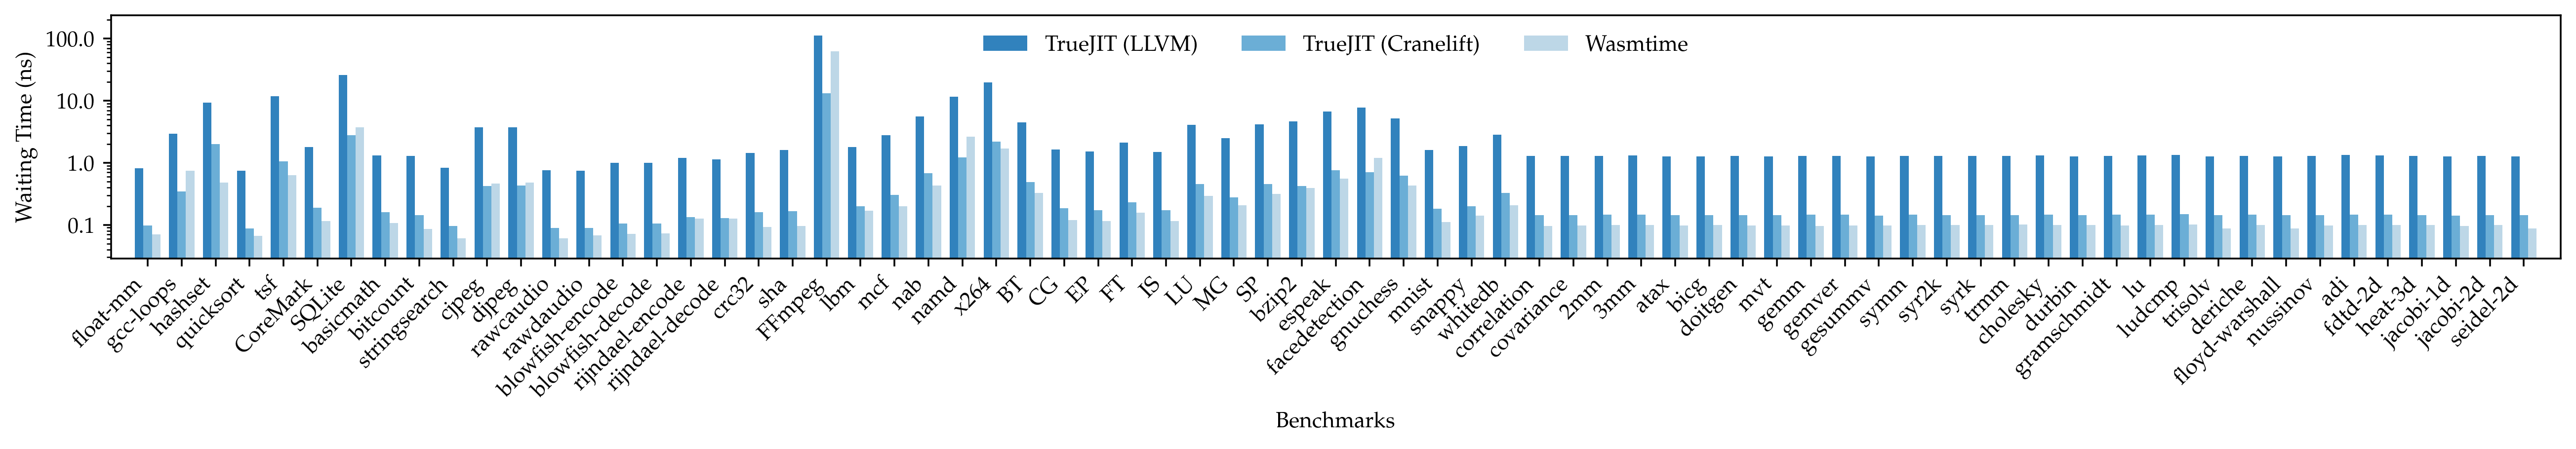

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import bokeh.palettes as bp

colors = bp.Blues5[1:-1]

fig, ax = plt.subplots(figsize=(20, 2), dpi=320)

barWidth = 0.25
r1 = np.arange(len(names))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]


ax.bar(r1, [w for (w, x, e) in truejit_llvm], color=colors[0], width=barWidth, label='TrueJIT (LLVM)')
ax.bar(r2, [w for (w, x, e) in truejit_cranelift], color=colors[1], width=barWidth, label='TrueJIT (Cranelift)')
ax.bar(r3, [w for (w, x, e) in wasmtime], color=colors[2], width=barWidth, label='Wasmtime')

ax.margins(0.01, 0.1)
ax.set_yscale('log')

def y_fmt(x, pos):
    return f'{x / 1_000_000_000}'
ax.yaxis.set_major_formatter(plt.FuncFormatter(y_fmt))


plt.xlabel('Benchmarks', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(names))], names, rotation=45, ha='right')
plt.ylabel('Waiting Time (s)', fontweight='bold')
plt.legend(loc='upper center', ncol=3, frameon=False)

# write to pdf
plt.savefig('out/compare-vms/waiting_time.pdf', bbox_inches='tight', pad_inches=0.1, dpi=320, format='pdf')

plt.show()

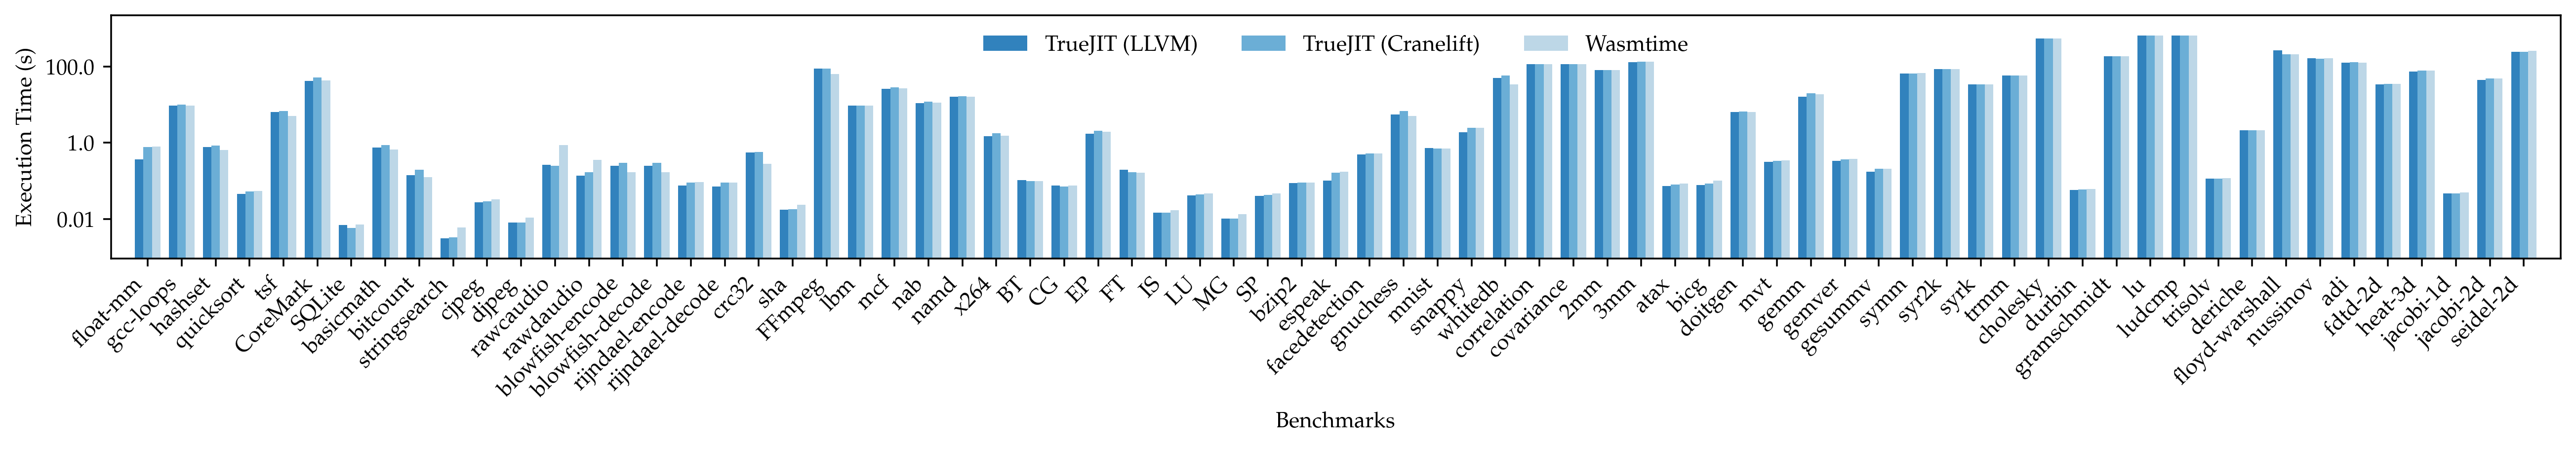

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import bokeh.palettes as bp

colors = bp.Blues5[1:-1]

fig, ax = plt.subplots(figsize=(20, 2), dpi=320)

barWidth = 0.25
r1 = np.arange(len(names))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]


ax.bar(r1, [x for (w, x, e) in truejit_llvm], color=colors[0], width=barWidth, label='TrueJIT (LLVM)')
ax.bar(r2, [x for (w, x, e) in truejit_cranelift], color=colors[1], width=barWidth, label='TrueJIT (Cranelift)')
ax.bar(r3, [x for (w, x, e) in wasmtime], color=colors[2], width=barWidth, label='Wasmtime')

ax.margins(0.01, 0.1)
ax.set_yscale('log')
def y_fmt(x, pos):
    return f'{x / 1_000_000_000}'
ax.yaxis.set_major_formatter(plt.FuncFormatter(y_fmt))


plt.xlabel('Benchmarks', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(names))], names, rotation=45, ha='right')
plt.ylabel('Execution Time (s)', fontweight='bold')
plt.legend(loc='upper center', ncol=3, frameon=False)

# write to pdf
plt.savefig('out/compare-vms/exec_time.pdf', bbox_inches='tight', pad_inches=0.1, dpi=320, format='pdf')

plt.show()

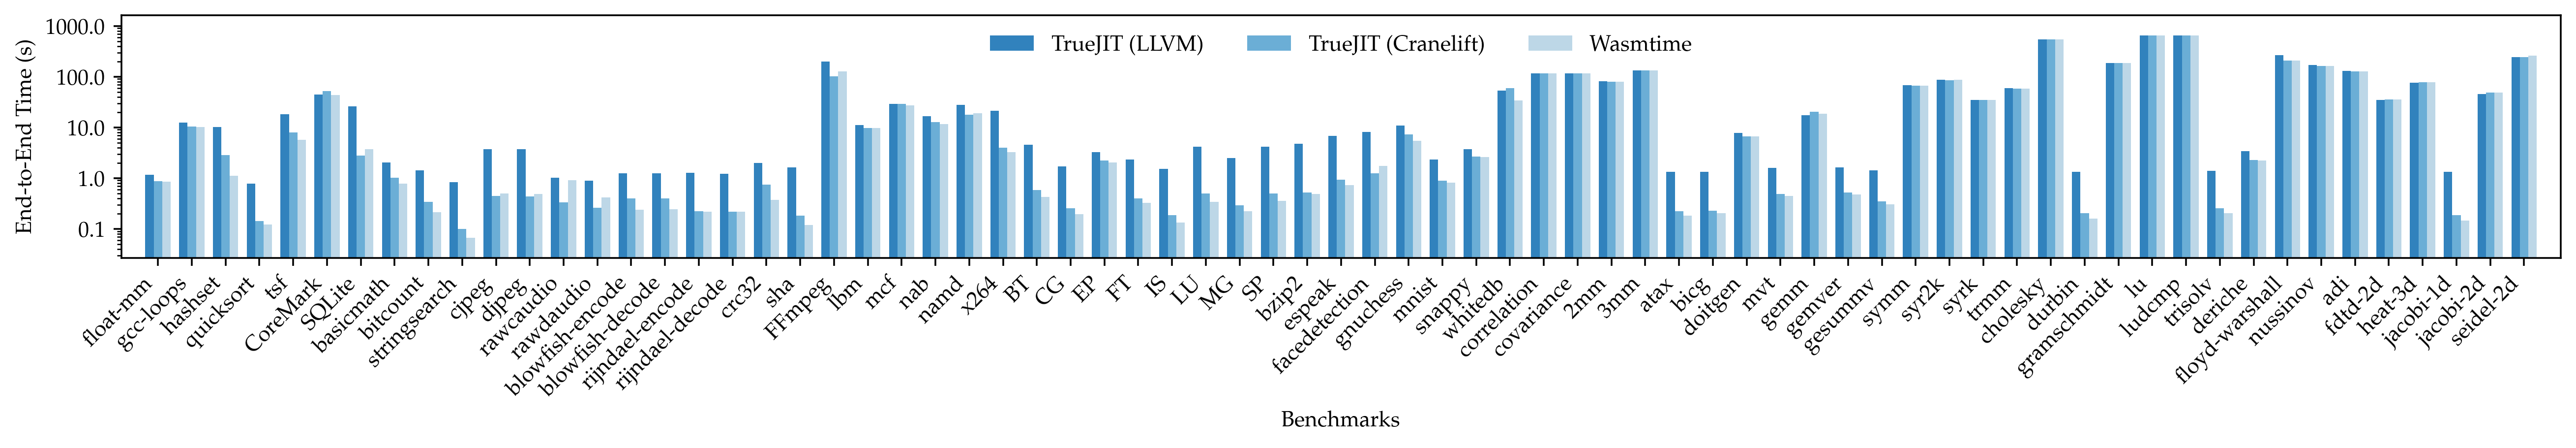

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import bokeh.palettes as bp

colors = bp.Blues5[1:-1]

fig, ax = plt.subplots(figsize=(20, 2), dpi=320)

barWidth = 0.25
r1 = np.arange(len(names))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]


ax.bar(r1, [e for (w, x, e) in truejit_llvm], color=colors[0], width=barWidth, label='TrueJIT (LLVM)')
ax.bar(r2, [e for (w, x, e) in truejit_cranelift], color=colors[1], width=barWidth, label='TrueJIT (Cranelift)')
ax.bar(r3, [e for (w, x, e) in wasmtime], color=colors[2], width=barWidth, label='Wasmtime')

ax.margins(0.01, 0.1)
ax.set_yscale('log')
def y_fmt(x, pos):
    return f'{x / 1_000_000_000}'
ax.yaxis.set_major_formatter(plt.FuncFormatter(y_fmt))


plt.xlabel('Benchmarks', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(names))], names, rotation=45, ha='right')
plt.ylabel('End-to-End Time (s)', fontweight='bold')
plt.legend(loc='upper center', ncol=3, frameon=False)

# write to pdf
plt.savefig('out/compare-vms/e2e_time.pdf', bbox_inches='tight', pad_inches=0.1, dpi=320, format='pdf')

plt.show()